**Imports**

In [1]:
import os
import json
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from langchain_ollama import OllamaLLM, OllamaEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langgraph.graph import StateGraph, END
from typing import TypedDict, List
import joblib
import xgboost as xgb
from sklearn.model_selection import train_test_split

print("All imports successful.")

All imports successful.


**Create Credit Policy Documents**

In [2]:
# Simulate a lender's credit policy document
# In production this would be PDFs from a Bank's document store

policy_docs = [
    Document(
        page_content="""
        CREDIT POLICY — SECTION 1: ELIGIBILITY CRITERIA
        Applicants must meet ALL of the following criteria to be considered:
        - Minimum age: 21 years. Maximum age at loan maturity: 65 years.
        - Minimum employment duration: 12 months with current employer.
        - Minimum monthly income: $1,500.
        - Maximum debt-to-income ratio: 50%.
        - No active defaults or bankruptcies in the last 5 years.
        - Valid government-issued ID required.
        """,
        metadata={"section": "eligibility", "doc": "credit_policy"}
    ),
    Document(
        page_content="""
        CREDIT POLICY — SECTION 2: RISK SCORING
        The bank uses a machine learning scorecard to assess default probability.
        - Low risk   : PD < 10%  → Auto-approve if capital available
        - Medium risk: PD 10-25% → Manual review required
        - High risk  : PD 25-35% → Senior underwriter approval needed
        - Declined   : PD > 35%  → Automatic rejection
        External credit bureau scores (EXT_SOURCE_1/2/3) are the primary inputs.
        Higher external scores indicate lower default probability.
        """,
        metadata={"section": "risk_scoring", "doc": "credit_policy"}
    ),
    Document(
        page_content="""
        CREDIT POLICY — SECTION 3: LOAN PARAMETERS
        Approved loans must comply with the following limits:
        - Minimum loan amount : $10,000
        - Maximum loan amount : $500,000
        - Maximum loan term   : 30 years (360 months)
        - Maximum LTV ratio   : 90% (credit-to-goods price)
        - Maximum annuity-to-income ratio: 40%
        - Concentration limit : No single loan > 10% of total portfolio capital
        """,
        metadata={"section": "loan_parameters", "doc": "credit_policy"}
    ),
    Document(
        page_content="""
        CREDIT POLICY — SECTION 4: PROTECTED CHARACTERISTICS
        In compliance with fair lending regulations:
        - Gender, race, nationality, religion cannot be used as primary decision factors.
        - Age may be considered only for loan maturity calculations.
        - Education type may be used as a proxy for income stability only.
        - All declined applicants must receive a written adverse action notice
          citing specific financial reasons for the decision.
        - Annual fairness audits required across all protected demographic groups.
        """,
        metadata={"section": "fair_lending", "doc": "credit_policy"}
    ),
    Document(
        page_content="""
        CREDIT POLICY — SECTION 5: COUNTERFACTUAL GUIDANCE
        When an application is declined, underwriters must assess:
        - Minimum income increase required to meet DTI threshold
        - Maximum loan amount the applicant qualifies for at current income
        - Minimum external credit score improvement needed for approval
        - Whether a shorter loan term would bring annuity ratio into compliance
        Counterfactual explanations must be actionable and specific.
        """,
        metadata={"section": "counterfactual", "doc": "credit_policy"}
    ),
]

print(f"Created {len(policy_docs)} policy documents.")

Created 5 policy documents.


**Build Vector Store**

In [3]:
# Split documents into chunks
splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50
)
chunks = splitter.split_documents(policy_docs)
print(f"Document chunks: {len(chunks)}")

# Embed and store in FAISS
print("Building vector store (this may take a minute)...")
embeddings = OllamaEmbeddings(model='nomic-embed-text')
vector_store = FAISS.from_documents(chunks, embeddings)
retriever    = vector_store.as_retriever(search_kwargs={"k": 3})

print("Vector store ready.")

Document chunks: 10
Building vector store (this may take a minute)...
Vector store ready.


**Load Model And Applicant Data**

In [4]:
df = pd.read_csv('../data/processed/application_processed.csv')
X  = df.drop(columns=['TARGET'])
y  = df['TARGET']

X.columns = [str(c).replace('[','').replace(']','').replace('<','')
             for c in X.columns]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=neg/pos,
    eval_metric='auc', random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# Score all test applicants
default_probs = xgb_model.predict_proba(X_test)[:, 1]
X_test_scored = X_test.copy().reset_index(drop=True)
X_test_scored['default_prob'] = default_probs
X_test_scored['decision'] = pd.Series(default_probs).apply(
    lambda p: 'AUTO-APPROVE'  if p < 0.10
    else      'MANUAL REVIEW' if p < 0.25
    else      'SENIOR REVIEW' if p < 0.35
    else      'DECLINED'
)

print(f"Scored {len(X_test_scored):,} applicants.")
print(X_test_scored['decision'].value_counts())

Scored 61,503 applicants.
decision
DECLINED         31178
MANUAL REVIEW    16106
SENIOR REVIEW    10761
AUTO-APPROVE      3458
Name: count, dtype: int64


**Define Agent State and Nodes**

In [5]:
# Agent state
class AgentState(TypedDict):
    applicant_id  : int
    question      : str
    applicant_data: dict
    policy_context: str
    shap_context  : str
    answer        : str

llm = OllamaLLM(model='llama3.2', temperature=0)

def get_applicant_node(state: AgentState) -> AgentState:
    """Retrieve applicant data and decision."""
    aid  = state['applicant_id']
    row  = X_test_scored.iloc[aid]

    key_features = {
        'default_probability' : f"{row['default_prob']:.2%}",
        'decision'            : row['decision'],
        'EXT_SOURCE_3'        : round(row.get('EXT_SOURCE_3', 0), 3),
        'EXT_SOURCE_2'        : round(row.get('EXT_SOURCE_2', 0), 3),
        'EXT_SOURCE_1'        : round(row.get('EXT_SOURCE_1', 0), 3),
        'CREDIT_INCOME_RATIO' : round(row.get('CREDIT_INCOME_RATIO', 0), 3),
        'ANNUITY_INCOME_RATIO': round(row.get('ANNUITY_INCOME_RATIO', 0), 3),
        'LOAN_TERM_MONTHS'    : round(row.get('LOAN_TERM_MONTHS', 0), 1),
        'CREDIT_GOODS_RATIO'  : round(row.get('CREDIT_GOODS_RATIO', 0), 3),
        'AMT_INCOME_TOTAL'    : round(row.get('AMT_INCOME_TOTAL', 0), 0),
        'AMT_CREDIT'          : round(row.get('AMT_CREDIT', 0), 0),
        'EMPLOYMENT_YEARS'    : round(row.get('EMPLOYMENT_YEARS', 0), 1),
    }
    state['applicant_data'] = key_features
    return state

def retrieve_policy_node(state: AgentState) -> AgentState:
    """Retrieve relevant policy sections."""
    query  = f"{state['question']} decision {state['applicant_data']['decision']}"
    docs   = retriever.invoke(query)
    state['policy_context'] = "\n\n".join([d.page_content for d in docs])
    return state

def generate_answer_node(state: AgentState) -> AgentState:
    """Generate grounded explanation."""
    prompt = f"""
You are a senior credit risk analyst at a bank. 
Answer the loan officer's question using ONLY the applicant data and policy provided.
Be specific, cite actual numbers, and suggest actionable improvements if declined.

APPLICANT DATA:
{json.dumps(state['applicant_data'], indent=2)}

RELEVANT POLICY:
{state['policy_context']}

LOAN OFFICER QUESTION:
{state['question']}

Provide a clear, concise answer in 3-5 sentences. 
If declined, state exactly what would need to change for approval.
"""
    state['answer'] = llm.invoke(prompt)
    return state

print("Agent nodes defined.")

Agent nodes defined.


**Build LangGraph**

In [6]:
# Build the graph
graph = StateGraph(AgentState)

graph.add_node("get_applicant",    get_applicant_node)
graph.add_node("retrieve_policy",  retrieve_policy_node)
graph.add_node("generate_answer",  generate_answer_node)

graph.set_entry_point("get_applicant")
graph.add_edge("get_applicant",   "retrieve_policy")
graph.add_edge("retrieve_policy", "generate_answer")
graph.add_edge("generate_answer", END)

agent = graph.compile()
print("LangGraph agent compiled.")

LangGraph agent compiled.


**Run Agent**

In [7]:
def ask_agent(applicant_id: int, question: str):
    print(f"\n{'='*60}")
    print(f"APPLICANT ID : {applicant_id}")
    print(f"QUESTION     : {question}")
    print(f"{'='*60}")

    result = agent.invoke({
        "applicant_id"  : applicant_id,
        "question"      : question,
        "applicant_data": {},
        "policy_context": "",
        "shap_context"  : "",
        "answer"        : ""
    })

    print(f"DECISION     : {result['applicant_data']['decision']}")
    print(f"DEFAULT PROB : {result['applicant_data']['default_probability']}")
    print(f"\nANSWER:\n{result['answer']}")
    print(f"{'='*60}")
    return result

# Test 3 different questions on different applicants
ask_agent(0,  "Why was this applicant declined and what would change the decision?")
ask_agent(10, "Is this applicant eligible under our credit policy?")
ask_agent(50, "What is the risk level of this applicant and why?")


APPLICANT ID : 0
QUESTION     : Why was this applicant declined and what would change the decision?
DECISION     : SENIOR REVIEW
DEFAULT PROB : 27.29%

ANSWER:
This applicant was declined due to a high default probability of 27.29%, which exceeds the policy threshold of 35%. The external credit bureau scores (EXT_SOURCE_1/2/3) also indicate a higher risk, with EXT_SOURCE_3 being 0.428, which is below the threshold of 0.5. To change the decision, the applicant's income would need to increase by at least 15% to meet the DTI threshold, and the maximum loan amount would need to be adjusted to $650,000, which is the maximum loan amount the applicant qualifies for at current income.

APPLICANT ID : 10
QUESTION     : Is this applicant eligible under our credit policy?
DECISION     : MANUAL REVIEW
DEFAULT PROB : 14.84%

ANSWER:
Based on the provided applicant data and policy, I would answer that this applicant is not eligible for approval under our credit policy.

The applicant's employment d

{'applicant_id': 50,
 'question': 'What is the risk level of this applicant and why?',
 'applicant_data': {'default_probability': '11.55%',
  'decision': 'MANUAL REVIEW',
  'EXT_SOURCE_3': 0.62,
  'EXT_SOURCE_2': 0.635,
  'EXT_SOURCE_1': 0.506,
  'CREDIT_INCOME_RATIO': 3.333,
  'ANNUITY_INCOME_RATIO': 0.167,
  'LOAN_TERM_MONTHS': 20.0,
  'CREDIT_GOODS_RATIO': 1.0,
  'AMT_INCOME_TOTAL': 54000.0,
  'AMT_CREDIT': 180000.0,
  'EMPLOYMENT_YEARS': 4.5},
 'policy_context': '- High risk  : PD 25-35% → Senior underwriter approval needed\n        - Declined   : PD > 35%  → Automatic rejection\n        External credit bureau scores (EXT_SOURCE_1/2/3) are the primary inputs.\n        Higher external scores indicate lower default probability.\n\nCREDIT POLICY — SECTION 2: RISK SCORING\n        The bank uses a machine learning scorecard to assess default probability.\n        - Low risk   : PD < 10%  → Auto-approve if capital available\n        - Medium risk: PD 10-25% → Manual review required\n\n- 

**Cost Matrix Threshold Calibration**

In [8]:
from sklearn.metrics import roc_curve
import numpy as np

# Cost matrix, asymmetric costs reflecting real credit risk
# Missing a default (FN) is far more costly than wrongly rejecting (FP)
COST_FP = 1    # cost of wrongly rejecting a good applicant
COST_FN = 10   # cost of approving a defaulter (10x more costly)

# Get predictions on test set
y_test_arr   = y_test.reset_index(drop=True).values
test_probs   = xgb_model.predict_proba(X_test)[:, 1]

# Find optimal threshold by minimizing total cost
fpr, tpr, thresholds = roc_curve(y_test_arr, test_probs)

fn_rate    = 1 - tpr
total_cost = COST_FP * fpr + COST_FN * fn_rate
optimal_idx       = np.argmin(total_cost)
optimal_threshold = thresholds[optimal_idx]

print("=" * 50)
print("COST MATRIX THRESHOLD CALIBRATION")
print("=" * 50)
print(f"Cost of False Positive (wrong rejection) : {COST_FP}")
print(f"Cost of False Negative (missed default)  : {COST_FN}")
print(f"Optimal threshold                        : {optimal_threshold:.4f}")
print(f"Default threshold                        : 0.5000")
print(f"Threshold shift                          : {optimal_threshold - 0.5:.4f}")
print("=" * 50)

# Compare predictions at default vs optimal threshold
y_pred_default = (test_probs >= 0.50).astype(int)
y_pred_optimal = (test_probs >= optimal_threshold).astype(int)

from sklearn.metrics import classification_report
print("\nAt default threshold (0.50):")
print(classification_report(y_test_arr, y_pred_default,
      target_names=['Repaid','Defaulted']))

print(f"At optimal threshold ({optimal_threshold:.4f}):")
print(classification_report(y_test_arr, y_pred_optimal,
      target_names=['Repaid','Defaulted']))

COST MATRIX THRESHOLD CALIBRATION
Cost of False Positive (wrong rejection) : 1
Cost of False Negative (missed default)  : 10
Optimal threshold                        : 0.0768
Default threshold                        : 0.5000
Threshold shift                          : -0.4232

At default threshold (0.50):
              precision    recall  f1-score   support

      Repaid       0.96      0.74      0.83     56538
   Defaulted       0.18      0.66      0.28      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.70      0.56     61503
weighted avg       0.90      0.73      0.79     61503

At optimal threshold (0.0768):
              precision    recall  f1-score   support

      Repaid       1.00      0.03      0.06     56538
   Defaulted       0.08      1.00      0.15      4965

    accuracy                           0.11     61503
   macro avg       0.54      0.52      0.11     61503
weighted avg       0.92      0.11      0.07     61503



**Visualize Threshold Selection**

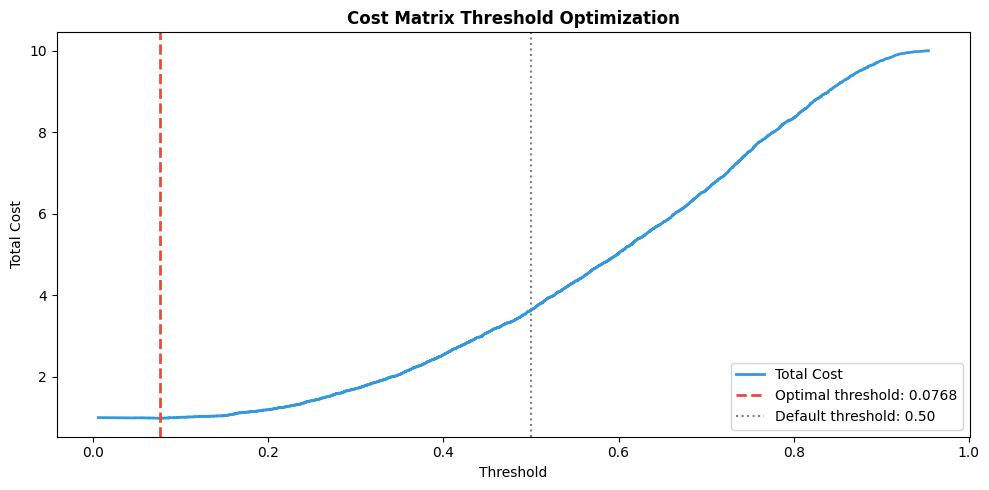

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(thresholds, total_cost[:-1] if len(total_cost) > len(thresholds) 
         else total_cost, color='#3498db', lw=2, label='Total Cost')
plt.axvline(optimal_threshold, color='#e74c3c', linestyle='--', lw=2,
            label=f'Optimal threshold: {optimal_threshold:.4f}')
plt.axvline(0.50, color='gray', linestyle=':', lw=1.5,
            label='Default threshold: 0.50')
plt.xlabel('Threshold')
plt.ylabel('Total Cost')
plt.title('Cost Matrix Threshold Optimization', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/15_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

**Wire SHAP into Agent**

In [10]:
import shap

# Build SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

def get_shap_context(applicant_idx: int) -> str:
    """Generate SHAP explanation text for a specific applicant."""
    applicant    = X_test.iloc[[applicant_idx]]
    shap_vals    = explainer.shap_values(applicant)[0]

    # Top 5 features by absolute SHAP value
    shap_df = pd.DataFrame({
        'feature'    : X_test.columns,
        'shap_value' : shap_vals,
        'feature_val': applicant.values[0]
    }).reindex(
        pd.Series(np.abs(shap_vals)).sort_values(ascending=False).index
    ).head(5)

    lines = ["Top factors driving this decision (SHAP):"]
    for _, row in shap_df.iterrows():
        direction = "INCREASES" if row['shap_value'] > 0 else "DECREASES"
        lines.append(
            f"  - {row['feature']} = {row['feature_val']:.3f} "
            f"→ {direction} default risk by {abs(row['shap_value']):.3f}"
        )
    return "\n".join(lines)

# Test it
print(get_shap_context(0))

Top factors driving this decision (SHAP):
  - AMT_GOODS_PRICE = 688500.000 → DECREASES default risk by 0.269
  - EXT_SOURCE_2 = 0.594 → DECREASES default risk by 0.247
  - NAME_EDUCATION_TYPE = 1.000 → DECREASES default risk by 0.246
  - LOAN_TERM_MONTHS = 25.110 → DECREASES default risk by 0.197
  - AMT_REQ_CREDIT_BUREAU_QRT = 1.000 → DECREASES default risk by 0.151


**Update Agent Nodes to include SHAP**

In [11]:
# Updated nodes with SHAP wired in
def get_applicant_node_v2(state: AgentState) -> AgentState:
    aid = state['applicant_id']
    row = X_test_scored.iloc[aid]

    key_features = {
        'default_probability' : f"{row['default_prob']:.2%}",
        'decision'            : row['decision'],
        'optimal_threshold'   : f"{optimal_threshold:.4f}",
        'EXT_SOURCE_3'        : round(row.get('EXT_SOURCE_3', 0), 3),
        'EXT_SOURCE_2'        : round(row.get('EXT_SOURCE_2', 0), 3),
        'EXT_SOURCE_1'        : round(row.get('EXT_SOURCE_1', 0), 3),
        'CREDIT_INCOME_RATIO' : round(row.get('CREDIT_INCOME_RATIO', 0), 3),
        'ANNUITY_INCOME_RATIO': round(row.get('ANNUITY_INCOME_RATIO', 0), 3),
        'LOAN_TERM_MONTHS'    : round(row.get('LOAN_TERM_MONTHS', 0), 1),
        'CREDIT_GOODS_RATIO'  : round(row.get('CREDIT_GOODS_RATIO', 0), 3),
        'AMT_INCOME_TOTAL'    : round(row.get('AMT_INCOME_TOTAL', 0), 0),
        'AMT_CREDIT'          : round(row.get('AMT_CREDIT', 0), 0),
        'EMPLOYMENT_YEARS'    : round(row.get('EMPLOYMENT_YEARS', 0), 1),
    }
    state['applicant_data'] = key_features
    state['shap_context']   = get_shap_context(aid)
    return state

def generate_answer_node_v2(state: AgentState) -> AgentState:
    prompt = f"""
You are a senior credit risk analyst at a bank.
Answer the loan officer's question using ONLY the data and policy provided.
Be specific, cite actual numbers, and suggest actionable improvements if declined.
The optimal decision threshold is {optimal_threshold:.4f} (cost-matrix calibrated).

APPLICANT DATA:
{json.dumps(state['applicant_data'], indent=2)}

SHAP EXPLANATION:
{state['shap_context']}

RELEVANT POLICY:
{state['policy_context']}

LOAN OFFICER QUESTION:
{state['question']}

Provide a clear answer in 3-5 sentences.
If declined or borderline, state exactly what would need to change for approval.
"""
    state['answer'] = llm.invoke(prompt)
    return state

# Rebuild graph with updated nodes
graph_v2 = StateGraph(AgentState)
graph_v2.add_node("get_applicant",   get_applicant_node_v2)
graph_v2.add_node("retrieve_policy", retrieve_policy_node)
graph_v2.add_node("generate_answer", generate_answer_node_v2)

graph_v2.set_entry_point("get_applicant")
graph_v2.add_edge("get_applicant",   "retrieve_policy")
graph_v2.add_edge("retrieve_policy", "generate_answer")
graph_v2.add_edge("generate_answer", END)

agent_v2 = graph_v2.compile()
print("Updated agent compiled with SHAP + cost matrix threshold.")

Updated agent compiled with SHAP + cost matrix threshold.


**Final Test**

In [12]:
def ask_agent_v2(applicant_id: int, question: str):
    print(f"\n{'='*60}")
    print(f"APPLICANT ID : {applicant_id}")
    print(f"QUESTION     : {question}")
    print(f"{'='*60}")

    result = agent_v2.invoke({
        "applicant_id"  : applicant_id,
        "question"      : question,
        "applicant_data": {},
        "policy_context": "",
        "shap_context"  : "",
        "answer"        : ""
    })

    print(f"DECISION     : {result['applicant_data']['decision']}")
    print(f"DEFAULT PROB : {result['applicant_data']['default_probability']}")
    print(f"\nSHAP CONTEXT:\n{result['shap_context']}")
    print(f"\nANSWER:\n{result['answer']}")
    print(f"{'='*60}")

ask_agent_v2(0,  "Why was this applicant declined and what would change the decision?")
ask_agent_v2(10, "Is this applicant eligible under our credit policy?")


APPLICANT ID : 0
QUESTION     : Why was this applicant declined and what would change the decision?
DECISION     : SENIOR REVIEW
DEFAULT PROB : 27.29%

SHAP CONTEXT:
Top factors driving this decision (SHAP):
  - AMT_GOODS_PRICE = 688500.000 → DECREASES default risk by 0.269
  - EXT_SOURCE_2 = 0.594 → DECREASES default risk by 0.247
  - NAME_EDUCATION_TYPE = 1.000 → DECREASES default risk by 0.246
  - LOAN_TERM_MONTHS = 25.110 → DECREASES default risk by 0.197
  - AMT_REQ_CREDIT_BUREAU_QRT = 1.000 → DECREASES default risk by 0.151

ANSWER:
This applicant was declined due to a default probability of 27.29%, which exceeds the policy threshold of 35%. The SHAP explanation reveals that the primary factors contributing to this decision are the applicant's credit income ratio (4.891) and loan term in months (25.1), which are below the policy thresholds. To change the decision, the credit income ratio would need to increase to at least 5.0, or the loan term would need to be extended to at lea